In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.functional import mse_loss
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import os
import random

# 设置随机种子
random.seed(42)
torch.manual_seed(42)
np.random.seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [2]:
# 加载数据
data_path = 'Full_Dataset.csv'  # 请根据实际路径修改
df_all = pd.read_csv(data_path, header=0)
df_all.rename(columns={df_all.columns[0]: 'time'}, inplace=True)
df_all['time'] = pd.to_datetime(df_all['time'], dayfirst=True)
df_all.set_index('time', inplace=True)

# 仅保留比利时本地特征
feature_cols = ['Price_BE', 'Wind_BE', 'Solar_BE', 'Load_BE']
df = df_all[feature_cols].copy()

# 异常值处理（5-sigma 截断）
price_mean = df['Price_BE'].mean()
price_std = df['Price_BE'].std()
upper_limit = price_mean + 5 * price_std
lower_limit = price_mean - 5 * price_std
df.loc[df['Price_BE'] > upper_limit, 'Price_BE'] = upper_limit
df.loc[df['Price_BE'] < lower_limit, 'Price_BE'] = lower_limit

# 缺失值填充
df = df.interpolate(method='time', limit=3)
for col in feature_cols:
    df[col] = df[col].fillna(df[col].shift(24))
df = df.bfill().ffill()

In [3]:
# 构造滞后特征（参考第6章）
lags = [24] #] + list(range(24*7, 24*35, 24))  # 24h, 168h, 192h, ..., 816h
for var in ['Price_BE']:
    for lag in lags:
        df[f'{var}_lag_{lag}'] = df[var].shift(lag)
        feature_cols.append(f'{var}_lag_{lag}')

# 构造时间特征
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['day_of_year'] = df.index.dayofyear
time_features = ['hour', 'day_of_week', 'day_of_year']
feature_cols.extend(time_features)

# 删除因滞后产生的缺失值
df = df.dropna()

In [4]:
train_size = int(0.7 * len(df))
val_size = int(0.85 * len(df))
train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:val_size].copy()
test_df = df.iloc[val_size:].copy()

In [5]:
# 分离特征和目标
X_train_raw = train_df[feature_cols].values
y_train_raw = train_df['Price_BE'].values.reshape(-1, 1)
X_val_raw = val_df[feature_cols].values
y_val_raw = val_df['Price_BE'].values.reshape(-1, 1)
X_test_raw = test_df[feature_cols].values
y_test_raw = test_df['Price_BE'].values.reshape(-1, 1)

In [6]:
def create_sequences(X, y, history_len=24, forecast_len=72):
    """
    X: 2D array of shape (total_timesteps, n_features)
    y: 1D array of shape (total_timesteps,)
    Returns:
        X_seq: shape (n_samples, history_len, n_features)
        y_seq: shape (n_samples, forecast_len)
    """
    X_seq, y_seq = [], []
    total = len(X) - history_len - forecast_len + 1
    for i in range(total):
        X_seq.append(X[i : i + history_len, :])
        y_seq.append(y[i + history_len : i + history_len + forecast_len].flatten())
    return np.array(X_seq), np.array(y_seq)

In [7]:
# 假设 X_train_scaled 形状为 (n_train, n_features)，y_train_scaled 形状为 (n_train,)
X_train_seq, y_train_seq = create_sequences(X_train_raw, y_train_raw)
X_val_seq, y_val_seq = create_sequences(X_val_raw, y_val_raw)
X_test_seq, y_test_seq = create_sequences(X_test_raw, y_test_raw)
print(f"X_train_seq shape: {X_train_seq.shape}")  # 应为 (样本数, 168, 特征数)
print(f"y_train_seq shape: {y_train_seq.shape}")  # 应为 (样本数, 72)

X_train_seq shape: (31488, 24, 8)
y_train_seq shape: (31488, 72)


In [8]:
print(f"y_val_seq shape: {y_val_seq.shape}")
print(f"X_val_seq shape: {X_val_seq.shape}")

y_val_seq shape: (6674, 72)
X_val_seq shape: (6674, 24, 8)


In [9]:
# 转换为 Tensor，并调整形状为 (batch, channels, time) 以匹配你的模型
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32).permute(0, 2, 1)  # (B, C, T)
y_train_t = torch.tensor(y_train_seq, dtype=torch.float32)
X_val_t = torch.tensor(X_val_seq, dtype=torch.float32).permute(0, 2, 1)
y_val_t = torch.tensor(y_val_seq, dtype=torch.float32)
X_test_t = torch.tensor(X_test_seq, dtype=torch.float32).permute(0, 2, 1)
y_test_t = torch.tensor(y_test_seq, dtype=torch.float32)
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)
print(f"训练批次: {len(train_loader)}, 验证批次: {len(val_loader)}")

训练批次: 984, 验证批次: 209


In [10]:
class ChannelAttention1D(nn.Module):
    """1D channel attention module for time series."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        reduced = max(channels // reduction, 4)
        self.mlp = nn.Sequential(
            nn.Conv1d(channels, reduced, 1, bias=False),
            nn.ReLU(),
            nn.Conv1d(reduced, channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.mlp(nn.AdaptiveAvgPool1d(1)(x))
        max_ = self.mlp(nn.AdaptiveMaxPool1d(1)(x))
        return self.sigmoid(avg + max_) * x

class ForecastModel(nn.Module):
    """
    Dual‑path CNN‑LSTM with bilinear fusion for 72‑hour electricity price forecasting.
    Input:  (batch, channels=7, time=168)
    Output: (batch, forecast_len=72)
    """
    def __init__(self, in_channels=7, forecast_len=72):
        super().__init__()
        # Spatial path (CNN + attention)
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            ChannelAttention1D(32),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            ChannelAttention1D(32),
            nn.AdaptiveAvgPool1d(1)
        )
        self.cnn_fc = nn.Linear(32, 32)

        # Temporal path (BiLSTM)
        self.lstm = nn.LSTM(input_size=in_channels, hidden_size=32,
                            num_layers=2, batch_first=True, bidirectional=False)
        self.lstm_fc = nn.Linear(32, 32)

        # Bilinear fusion + final regressor
        self.regressor = nn.Sequential(
            nn.Linear(32 + 32, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, forecast_len)
        )

    def forward(self, x):
        B, C, T = x.shape

        # Spatial features
        cnn_out = self.cnn(x).view(B, -1)
        s_vec = self.cnn_fc(cnn_out)                     # (B, 64)

        # Temporal features
        lstm_in = x.permute(0, 2, 1)                      # (B, T, C)
        lstm_out, _ = self.lstm(lstm_in)
        t_vec = self.lstm_fc(lstm_out[:, -1, :])          # (B, 64)

        # Bilinear fusion
        fusion = torch.cat([s_vec, t_vec], dim=1)# torch.bmm(t_vec.unsqueeze(2), s_vec.unsqueeze(1))  # (B, 64, 64)
        fusion = fusion.view(B, -1)                                 # (B, 4096)

        return self.regressor(fusion)                     # (B, 72)

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ForecastModel(in_channels=len(feature_cols), forecast_len=72).to(device)
criterion = nn.HuberLoss(delta=5.0)           # evaluation metric (MSE)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5, eps=1e-6)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(model)
print(f"Using device: {device}")

ForecastModel(
  (cnn): Sequential(
    (0): Conv1d(8, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ChannelAttention1D(
      (mlp): Sequential(
        (0): Conv1d(32, 8, kernel_size=(1,), stride=(1,), bias=False)
        (1): ReLU()
        (2): Conv1d(8, 32, kernel_size=(1,), stride=(1,), bias=False)
      )
      (sigmoid): Sigmoid()
    )
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): ChannelAttention1D(
      (mlp): Sequential(
        (0): Conv1d(32, 8, kernel_size=(1,), stride=(1,), bias=False)
        (1): ReLU()
        (2): Conv1d(8, 32, kernel_size=(1,), stride=(1,), bias=False)
      )
      (sigmoid): Sigmoid()
    )
    (9): AdaptiveAvgPoo

In [12]:
num_epochs = 500
best_val_loss = float('inf')
best_model_path = 'best_model.pth'
patience_counter = 0
early_stop_patience = 50

train_losses, val_losses = [], []

for epoch in range(num_epochs):
    # 训练
    model.train()
    total_train = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_train += loss.item() * xb.size(0)
        del xb, yb, pred, loss
        torch.cuda.empty_cache()
    avg_train = total_train / len(train_loader.dataset)
    train_losses.append(avg_train)

    # 验证
    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            total_val += loss.item() * xb.size(0)
        del xb, yb, pred, loss
        torch.cuda.empty_cache()
    avg_val = total_val / len(val_loader.dataset)
    val_losses.append(avg_val)

    # scheduler.step(avg_val)

    # 保存最佳模型
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
        print(f"Epoch {epoch+1}: 保存新最佳模型，验证损失 = {avg_val:.6f}")
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"早停于 epoch {epoch+1}")
            break

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | 训练损失: {avg_train:.6f} | 验证损失: {avg_val:.6f}")

Epoch 1: 保存新最佳模型，验证损失 = 152.684696
Epoch 3: 保存新最佳模型，验证损失 = 151.170547
Epoch 5: 保存新最佳模型，验证损失 = 145.887980
Epoch 5/500 | 训练损失: 183.934797 | 验证损失: 145.887980
Epoch 6: 保存新最佳模型，验证损失 = 143.857238
Epoch 8: 保存新最佳模型，验证损失 = 143.168252
Epoch 9: 保存新最佳模型，验证损失 = 132.556775
Epoch 10: 保存新最佳模型，验证损失 = 129.623701
Epoch 10/500 | 训练损失: 162.516715 | 验证损失: 129.623701
Epoch 11: 保存新最佳模型，验证损失 = 126.521266
Epoch 13: 保存新最佳模型，验证损失 = 123.808248
Epoch 15/500 | 训练损失: 156.141666 | 验证损失: 125.038722
Epoch 16: 保存新最佳模型，验证损失 = 123.747147
Epoch 19: 保存新最佳模型，验证损失 = 123.597407
Epoch 20/500 | 训练损失: 150.208015 | 验证损失: 141.164647
Epoch 24: 保存新最佳模型，验证损失 = 122.753044
Epoch 25/500 | 训练损失: 146.202474 | 验证损失: 126.687761
Epoch 29: 保存新最佳模型，验证损失 = 121.065891
Epoch 30/500 | 训练损失: 143.789668 | 验证损失: 130.482791
Epoch 31: 保存新最佳模型，验证损失 = 121.009110
Epoch 35/500 | 训练损失: 140.054031 | 验证损失: 121.519484
Epoch 37: 保存新最佳模型，验证损失 = 120.165801
Epoch 39: 保存新最佳模型，验证损失 = 120.024374
Epoch 40/500 | 训练损失: 138.064763 | 验证损失: 126.411059
Epoch 45/500 | 训练损失: 14

In [18]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
total_loss = 0.0
all_preds = []
all_targets = []

mse_loss = nn.MSELoss()
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)

        # 累积 MSE loss（可选，如果只需要最终指标可以不计算）
        loss = mse_loss(pred, yb)
        total_loss += loss.item() * xb.size(0)

        # 收集预测和真实值（在归一化尺度）
        all_preds.append(pred.cpu().numpy())
        all_targets.append(yb.cpu().numpy())

# 计算平均 MSE（归一化尺度）
avg_mse = total_loss / len(test_loader.dataset)
print(f"Test MSE (normalized): {avg_mse:.6f}")

Test MSE (normalized): 948.542983


In [26]:
# Last 168 hours from the whole dataset
last_window = X_test_seq[-1]                    # (168, 7)
last_tensor = torch.tensor(last_window, dtype=torch.float32).unsqueeze(0).permute(0, 2, 1).to(device)  # (1, 7, 168)

model.eval()
with torch.no_grad():
    pred = model(last_tensor).cpu().numpy()     # (1, 72)
true = y_test_seq[-1]                      # (72,)
pred_future = pred.reshape(-1, 1)
# Save as required by the assignment (72 rows, no header, no index)
np.savetxt('predictions.csv', pred_future, delimiter=',', fmt='%.6f')
print("predictions.csv saved with 72 hourly forecasts.")

predictions.csv saved with 72 hourly forecasts.


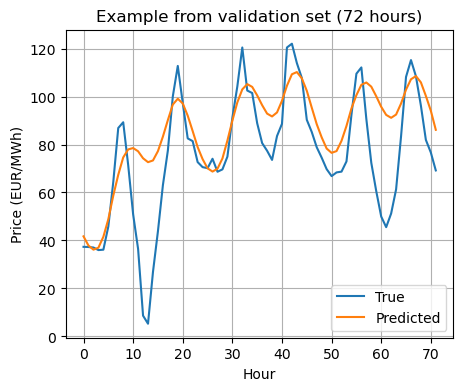

In [27]:
plt.figure(figsize=(5,4))
plt.plot(true, label='True')
plt.plot(pred_future, label='Predicted')
plt.legend()
plt.title('Example from validation set (72 hours)')
plt.xlabel('Hour')
plt.ylabel('Price (EUR/MWh)')
plt.grid(True)
plt.savefig('predictions.pdf')
plt.show()

In [29]:
np.mean((true - pred_future) ** 2)

np.float64(1114.100699355401)

In [30]:
np.mean(np.abs(true-pred_future)/np.abs(true))

np.float64(0.7384467992113937)